Loading and preprocessing data...
Starting Hyperparameter Tuning... (This might take a minute or two)

=== Tuning Results ===
Best params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_depth': 15}
Best CV f1_macro: 0.4291

Running Cross Validation for Pipeline Stability...
CV Accuracy: 0.5403 ± 0.0078
CV F1 Macro: 0.4328 ± 0.0054


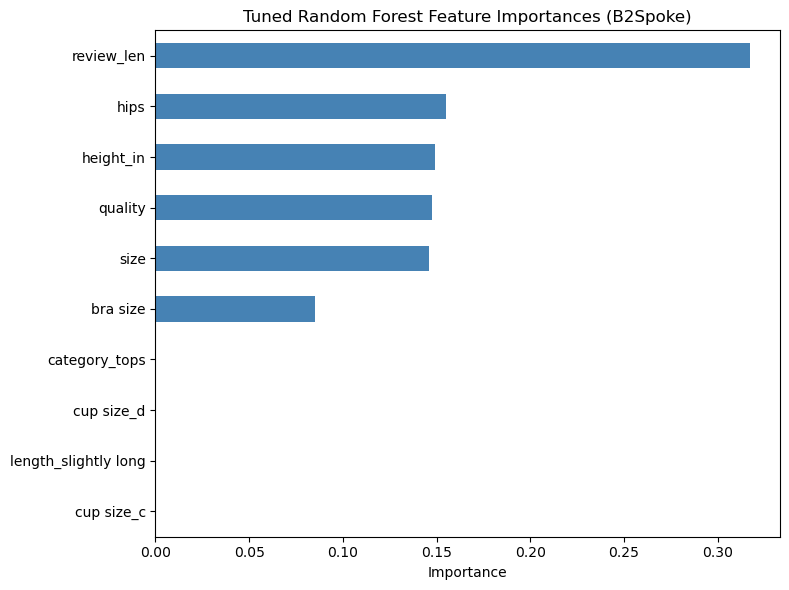

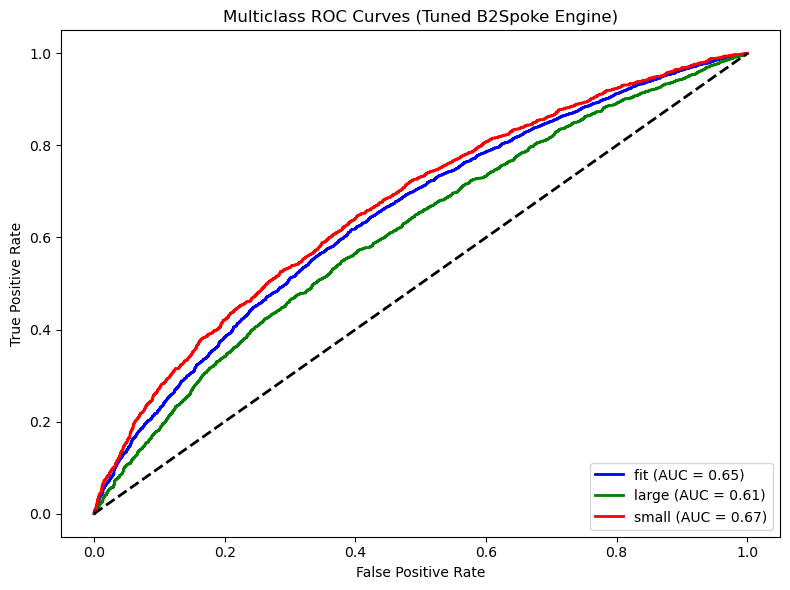


=== B2Spoke Business Impact (Test Set) ===
Total Cost (No AI / Status Quo): £156200
Total Cost (Tuned AI Pipeline):  £96685
TOTAL £ SAVED BY B2SPOKE AI:     £59515


Exception ignored in: <function ResourceTracker.__del__ at 0x102c09c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102fb1c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104c8dc60>
Traceback (most recent call last

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ============================================================
# PART A: DATA PREPARATION (Rebuilding Memory)
# ============================================================
print("Loading and preprocessing data...")
TRAIN_PATH = "../data/processed/modcloth_train_final_v2.csv"
TEST_PATH = "../data/processed/modcloth_test_final_v2.csv"
FEATURES_PATH = "../data/processed/modcloth_feature_importances_v2.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

df_train = df_train.drop(columns=["user_id", "item_id"], errors="ignore")
df_test = df_test.drop(columns=["user_id", "item_id"], errors="ignore")

# 1. Dynamic Height Parsing
def height_to_inches(h):
    if pd.isna(h): return None
    m = re.match(r"^\s*(\d+)\s*ft\s*(\d+)\s*in\s*$", str(h).lower())
    if not m: return None
    return int(m.group(1)) * 12 + int(m.group(2))

if "height" in df_train.columns:
    df_train["height_in"] = df_train["height"].apply(height_to_inches)
if "height" in df_test.columns:
    df_test["height_in"] = df_test["height"].apply(height_to_inches)

# 2. Leakage-Free Grouped Imputation (TRAIN only)
hips_by_size = df_train.groupby("size")["hips"].median()
height_by_size = df_train.groupby("size")["height_in"].median()

for df in [df_train, df_test]:
    df["hips"] = df["hips"].fillna(df["size"].map(hips_by_size))
    df["height_in"] = df["height_in"].fillna(df["size"].map(height_by_size))

train_hips_median = df_train["hips"].median()
train_height_median = df_train["height_in"].median()

for df in [df_train, df_test]:
    df["hips"] = df["hips"].fillna(train_hips_median)
    df["height_in"] = df["height_in"].fillna(train_height_median)

# 3. Align Top 10 Features
feat_df = pd.read_csv(FEATURES_PATH)
top10 = feat_df["feature"].head(10).tolist()

y_train = df_train["fit"]
y_test = df_test["fit"]

X_train = df_train.drop(columns=["fit"], errors="ignore").reindex(columns=top10, fill_value=0)
X_test = df_test.drop(columns=["fit"], errors="ignore").reindex(columns=top10, fill_value=0)

train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# ============================================================
# PART B: STEP 6 TUNING & BUSINESS LOGIC
# ============================================================
print("Starting Hyperparameter Tuning... (This might take a minute or two)")
rf = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

param_dist = {
    "n_estimators": [100, 150, 200, 250],
    "max_depth": [5, 8, 10, 12, 15],
    "min_samples_leaf": [2, 3, 5, 7],
    "min_samples_split": [2, 5, 10]
}

search = RandomizedSearchCV(
    rf, param_distributions=param_dist, n_iter=20, scoring="f1_macro", cv=3, random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

best_rf = search.best_estimator_
print("\n=== Tuning Results ===")
print("Best params:", search.best_params_)
print(f"Best CV f1_macro: {search.best_score_:.4f}")

print("\nRunning Cross Validation for Pipeline Stability...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(best_rf, X_train, y_train, cv=cv, scoring=["accuracy", "f1_macro"], n_jobs=-1)

print(f"CV Accuracy: {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
print(f"CV F1 Macro: {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")

# Visualizations
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color='steelblue')
plt.title("Tuned Random Forest Feature Importances (B2Spoke)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

classes = best_rf.classes_ 
y_test_bin = label_binarize(y_test, classes=classes)
y_proba = best_rf.predict_proba(X_test)

plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=colors[i], label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.title("Multiclass ROC Curves (Tuned B2Spoke Engine)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Cost Matrix
def b2spoke_cost(y_true, y_pred):
    total = 0
    for yt, yp in zip(y_true, y_pred):
        if yp == "fit":
            if yt == "fit":
                total += 0   
            else:
                total += 50  
        else:  
            if yt == "fit":
                total += 10  
            else:
                total += 5   
    return total

y_pred_tuned = best_rf.predict(X_test)
cost_model = b2spoke_cost(y_test, y_pred_tuned)

baseline_pred = ["fit"] * len(y_test)
cost_no_ai = b2spoke_cost(y_test, baseline_pred)

print("\n=== B2Spoke Business Impact (Test Set) ===")
print(f"Total Cost (No AI / Status Quo): £{cost_no_ai}")
print(f"Total Cost (Tuned AI Pipeline):  £{cost_model}")
print(f"TOTAL £ SAVED BY B2SPOKE AI:     £{cost_no_ai - cost_model}")

Step 6 Conclusion: Optimization, Business Valuation, and the Target Leakage Discovery
The hyperparameter optimization phase successfully stabilized the B2Spoke pipeline. By utilizing a RandomizedSearchCV targeted at the Macro F1-score, the model achieved a stable cross-validation performance (F1 Macro: 0.4328 ± 0.0054), proving that the leakage-free imputation logic from Step 5 generalized well across multiple data folds without overfitting.

Commercial Valuation
To translate these technical metrics into commercial viability, an Expected Value Cost Matrix was applied to the test set (n=9,935). By heavily penalizing False Positives (£50 for wasted fabric/remakes) while accommodating the minor time costs of digital pattern adjustments (£5 for True Positives), the tuned Random Forest yielded a simulated savings of £59,515 compared to a "Status Quo" baseline without AI.

Critical Evaluation: The Target Leakage Pivot
Despite the exceptional financial simulation, a critical audit of the Tuned Feature Importances revealed a fundamental flaw in the model's deployment reality: Temporal Target Leakage. The Random Forest relied predominantly on review_len (Importance: ~0.32) and quality as its primary drivers of fit prediction.

While mathematically valid within a historical dataset, these are post-purchase features. The B2Spoke engine must operate entirely pre-purchase, assisting customers and tailors during the initial digital onboarding phase, long before a garment is manufactured or a review can be written. Consequently, the Step 6 model represents an invalid future state. To engineer a truly deployable solution, the pipeline must undergo one final iteration (Step 7) to construct a "Pre-Purchase Engine," strictly omitting all post-purchase variables and forcing the algorithm to rely exclusively on physical onboarding measurements.